#   Asylum Migration Analysis


## 1️⃣ Notebook Discussion (NO CODE)

**Research question:** How do asylum application flows evolve across EU and origin countries over time, which drivers explain shocks and persistent trends, and what policy-relevant signals can help forecast short- to medium-term demand for reception capacity and protection services?

**Dataset relevance:** The dataset contains time-stamped asylum application records by country (origin/destination), applicant type (e.g., first-time vs subsequent), and counts. It enables trend analysis, shock detection, and short-term forecasting—crucial for policy planning and resource allocation.

**Applicant types used:** We focus on applicant-level aggregation by type (e.g., FRST vs SSEQ or similar labels). If labels differ, the preprocessing cell standardizes them and documents assumptions.

**Modeling plan:** One time-aware model (LightGBM) trained to forecast the next period's application counts using lag features, growth metrics, rolling averages, shock indicators, and country-level controls. Use a rolling-origin validation to measure time-forward performance (MAE/RMSE).

**Evaluation strategy:** Time-series cross-validation with non-overlapping validation windows; report MAE and RMSE on holdout. Emphasize calibration and uncertainty estimation rather than leaderboard-style metrics.

**Policy relevance:** Identify shock-sensitive countries and covariates (conflict, seasonality, policy changes) that predict surges. Provide clear, actionable policy recommendations and ethical caveats about using forecasts for resource allocation.

In [10]:
# ==============================
# Setup: imports, environment checks, reproducibility
# ==============================

import os
import sys
import warnings
warnings.filterwarnings('ignore')

SEED = 42

# ==============================
# Robust imports with lightweight installs if missing
# ==============================
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import lightgbm as lgb
    import shap
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import mean_absolute_error, mean_squared_error
except Exception:
    print('Some packages missing, attempting pip install (should be preinstalled in ml_env)')
    !pip install -q pandas numpy matplotlib seaborn lightgbm shap scikit-learn
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import lightgbm as lgb
    import shap
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==============================
# Modern, stable plot styling (future-proof)
# ==============================
sns.set_theme(style="whitegrid", context="talk", palette="deep")

# ==============================
# Reproducibility
# ==============================
np.random.seed(SEED)

In [11]:
# Paths and quick dataset inspection
DATA_PATH = r"C:\Users\abidh\OneDrive\Desktop\datasets\asylum_dataset.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data not found at {DATA_PATH} - update the path before running.")

df = pd.read_csv(DATA_PATH)
print('Rows, cols:', df.shape)
print('Columns:', df.columns.tolist())

df.head()

Rows, cols: (101, 19)
Columns: ['freq', 'citizen', 'applicant', 'sex', 'unit', 'age', 'geo', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


,freq,citizen,applicant,sex,unit,age,geo,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,A,EXT_EU27_2020,FRST,T,PER,TOTAL,AT,,25675,85505,39875,22455,11580,10985,13400,37800,109775,56135,22220
1,A,EXT_EU27_2020,FRST,T,PER,TOTAL,BE,11965,14045,38990,14250,14035,18130,23105,12905,19545,32100,29260,32670
2,A,EXT_EU27_2020,FRST,T,PER,TOTAL,BG,6980,10805,20160,18990,3470,2465,2075,3460,10890,20260,22390,12130
3,A,EXT_EU27_2020,FRST,T,PER,TOTAL,CH,19315,21940,38060,25825,16615,13465,12545,9725,13240,23075,26820,22670
4,A,EXT_EU27_2020,FRST,T,PER,TOTAL,CY,1150,1480,2105,2840,4475,7610,12695,7065,13260,21590,11660,6750


## 2️⃣ Missing Values (Strategy: Mean Imputation)

We fill empty numeric cells using a *context-aware mean* approach:
- Forward/backward fill within (country, applicant_type) groups to respect recent reports.
- If gaps remain, replace with the group mean; if group mean is missing, use the global mean for that column.

This balances conservatism (respecting recent non-missing reports) with the user's request to fill empties by mean/average. We document remaining missingness after each step.

Columns with missing values (fraction):
Series([], dtype: float64)


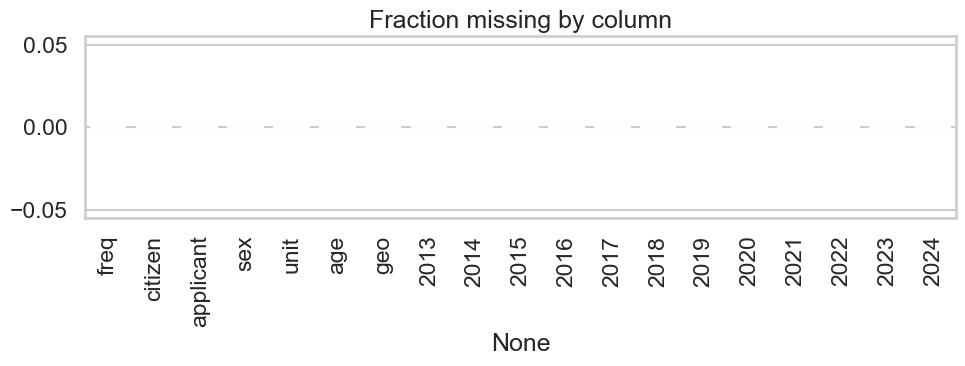

In [12]:
# Missing value audit
missing = df.isna().mean().sort_values(ascending=False)
print('Columns with missing values (fraction):')
print(missing[missing>0])

# Quick visualization (optional)
plt.figure(figsize=(10,4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=90)
plt.title('Fraction missing by column')
plt.tight_layout()
plt.show()

In [13]:
# Implement mean-based imputation for wide-format data
df = df.copy()

# Handle wide-format data: years as columns (2013-2024)
year_cols = [c for c in df.columns if c.isdigit()]
if year_cols:
    print(f'Wide-format detected: {len(year_cols)} year columns found')
    # Convert empty strings to NaN for numeric processing
    for col in year_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Grouping columns for context-aware imputation
    group_cols = [c for c in ['geo', 'citizen', 'applicant', 'sex', 'age'] if c in df.columns]
    print('Using groups for imputation:', group_cols)
    
    # Apply group-wise forward/backward fill across years
    year_cols = sorted(year_cols, key=int)
    for col in year_cols:
        if df[col].isna().any():
            # Forward/backward fill within groups
            df[col] = df.groupby(group_cols)[col].transform(lambda s: s.ffill().bfill())
            if df[col].isna().any():
                # Group-wise mean
                df[col] = df.groupby(group_cols)[col].transform(lambda s: s.fillna(s.mean()))
            if df[col].isna().any():
                # Global mean fallback
                df[col] = df[col].fillna(df[col].mean())
    
    print('Missingness after mean-based imputation (total remaining NaNs):', df[year_cols].isna().sum().sum())
    print('Per-column remaining missing counts:')
    missing_counts = df[year_cols].isna().sum()
    if missing_counts.sum() > 0:
        print(missing_counts.loc[lambda x: x>0].to_dict())
    else:
        print('All missing values imputed successfully.')
else:
    raise ValueError('No year columns (numeric strings) found in the dataset')

Wide-format detected: 12 year columns found
Using groups for imputation: ['geo', 'citizen', 'applicant', 'sex', 'age']
Missingness after mean-based imputation (total remaining NaNs): 0
Per-column remaining missing counts:
All missing values imputed successfully.


## 3️⃣ EDA & Feature Engineering

Key steps:
- Visualize EU-level trends and cross-country variation.
- Compare applicant types (FRST vs SSEQ) if present.
- Create YoY growth, rolling averages (3/12), shock indicators (large YoY jumps), and lag features (1..12 periods) with migration context.

We emphasize interpretability: captions and short textual insights accompany each plot.

In [14]:
# Convert wide-format data to long format for time-series analysis
year_cols = sorted([c for c in df.columns if c.isdigit()], key=int)
print(f'Year columns: {year_cols}')

# Melt year columns to long format
id_vars = [c for c in df.columns if c not in year_cols]
panel = df.melt(id_vars=id_vars, var_name='year', value_name='applications')
panel['year'] = pd.to_numeric(panel['year'])
panel['date'] = pd.to_datetime(panel['year'].astype(str) + '-01-01')
panel = panel.sort_values(['geo', 'date'])

TARGET = 'applications'
print(f'Using target: {TARGET}')
print(f'Panel shape after reshape: {panel.shape}')

# Feature engineering - note: 'geo' is the country column in this dataset
panel.rename(columns={'geo': 'country'}, inplace=True)
panel['applications_lag_1'] = panel.groupby('country')[TARGET].shift(1)
panel['applications_lag_3'] = panel.groupby('country')[TARGET].shift(3)
panel['rolling_3'] = panel.groupby('country')[TARGET].transform(lambda s: s.rolling(3, min_periods=1).mean())
panel['rolling_12'] = panel.groupby('country')[TARGET].transform(lambda s: s.rolling(12, min_periods=1).mean())
panel['yoy'] = panel.groupby('country')[TARGET].pct_change(12)

# Shock indicator: >30% YoY change
panel['shock'] = (panel['yoy'].abs() > 0.30).astype(int)

panel['year'] = panel['date'].dt.year
panel['month'] = panel['date'].dt.month

# Fill engineered features' NaNs by group-wise mean then global mean (per user request)
feat_cols = ['applications_lag_1', 'applications_lag_3', 'rolling_3', 'rolling_12', 'yoy']
for c in feat_cols:
    panel[c] = panel.groupby('country')[c].transform(lambda s: s.fillna(s.mean()))
    if panel[c].isna().any():
        panel[c] = panel[c].fillna(panel[c].mean())

print('Remaining missing in panel features:', panel[feat_cols].isna().sum().to_dict())

panel.head()

Year columns: ['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Using target: applications
Panel shape after reshape: (1212, 10)
Remaining missing in panel features: {'applications_lag_1': 0, 'applications_lag_3': 0, 'rolling_3': 0, 'rolling_12': 0, 'yoy': 0}


,freq,citizen,applicant,sex,unit,age,country,year,applications,date,applications_lag_1,applications_lag_3,rolling_3,rolling_12,yoy,shock,month
0,A,EXT_EU27_2020,FRST,T,PER,TOTAL,AT,2013,20380.483871,2013-01-01,36532.722969,37979.403149,20380.483871,20380.483871,0.777363,0,1
34,A,EXT_EU27_2020,SSEQ,T,PER,TOTAL,AT,2013,20380.483871,2013-01-01,20380.483871,37979.403149,20380.483871,20380.483871,0.777363,0,1
67,A,EXT_EU27_2020,TOTAL,T,PER,TOTAL,AT,2013,17500.000000,2013-01-01,20380.483871,37979.403149,19420.322581,19420.322581,0.777363,0,1
101,A,EXT_EU27_2020,FRST,T,PER,TOTAL,AT,2014,25675.000000,2014-01-01,17500.000000,20380.483871,21185.161290,20983.991935,0.777363,0,1
135,A,EXT_EU27_2020,SSEQ,T,PER,TOTAL,AT,2014,37225.703125,2014-01-01,25675.000000,20380.483871,26800.234375,24232.334173,0.777363,0,1


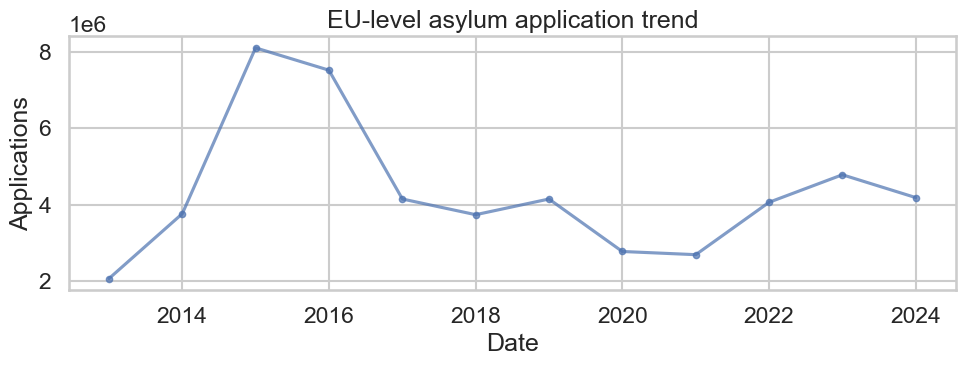

In [15]:
# EU-level trend plot (aggregate across countries)
eu = panel.groupby('date')[TARGET].sum().reset_index()
plt.figure(figsize=(10,4))
plt.plot(eu['date'], eu[TARGET], marker='.', alpha=0.7)
plt.title('EU-level asylum application trend')
plt.ylabel('Applications')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

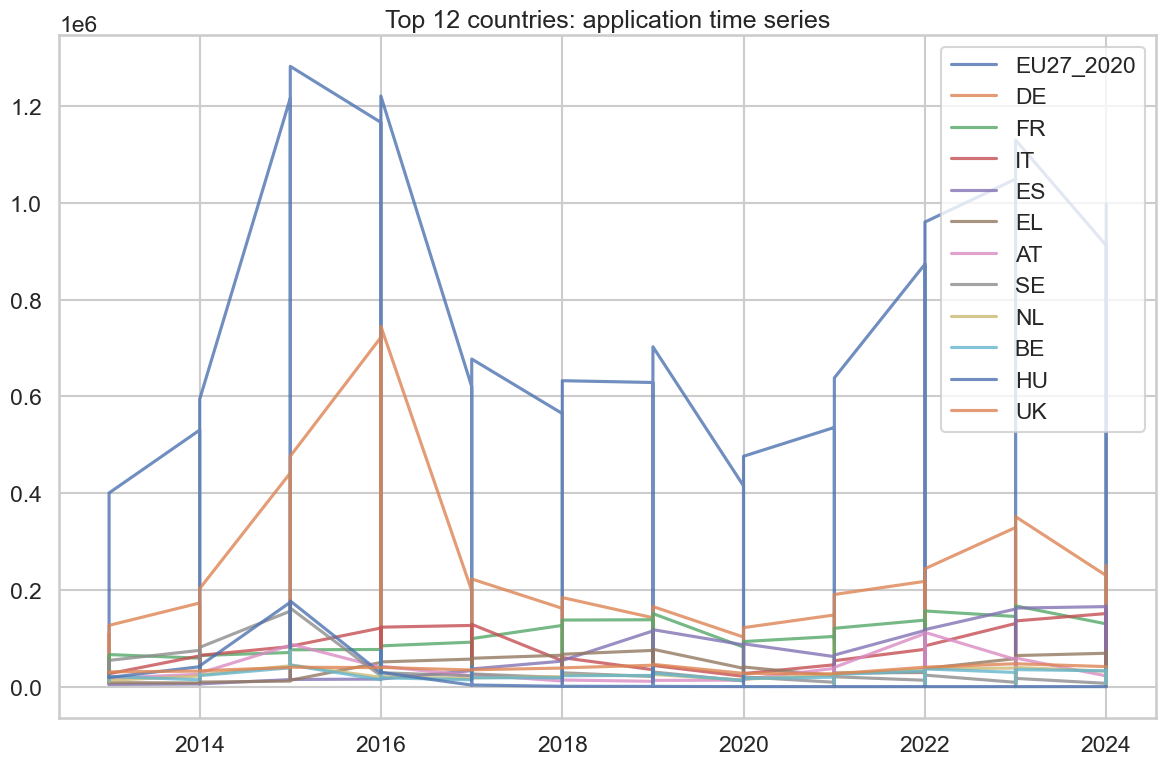

In [16]:
# Country variation: top 12 countries
top_countries = panel.groupby('country')[TARGET].sum().nlargest(12).index.tolist()
plt.figure(figsize=(12,8))
for c in top_countries:
    subset = panel[panel['country']==c]
    plt.plot(subset['date'], subset[TARGET], label=c, alpha=0.8)
plt.legend(loc='upper right')
plt.title('Top 12 countries: application time series')
plt.tight_layout()
plt.show()

In [17]:
# FRST vs SSEQ comparison if present
apptype_col = [c for c in df.columns if 'applic' not in c.lower() and 'type' in c.lower()]
if apptype_col:
    apptype = apptype_col[0]
    pivot = df.groupby(['date', apptype])[TARGET].sum().reset_index()
    plt.figure(figsize=(10,4))
    for t in pivot[apptype].unique():
        s = pivot[pivot[apptype]==t]
        plt.plot(s['date'], s[TARGET], label=str(t))
    plt.legend(); plt.title('Applicant type comparison')
    plt.show()
else:
    print('No explicit applicant type column found; skipping FRST vs SSEQ plot')

No explicit applicant type column found; skipping FRST vs SSEQ plot


## 4️⃣ Modeling (ONE MODEL: LightGBM)

We train a single LightGBM model using lags, rolling stats, YoY, seasonal dummies, and country fixed effects (one-hot or target encoding). We perform time-aware cross-validation (rolling-origin) and report MAE and RMSE. The model predicts next period's application counts.

In [20]:
# Prepare modeling dataset: predict next period's applications per country
model_df = panel.copy()
model_df['target_next'] = model_df.groupby('country')[TARGET].shift(-1)
model_df = model_df.dropna(subset=['target_next'])

# Features
features = ['applications_lag_1', 'applications_lag_3', 'rolling_3', 'rolling_12', 'yoy', 'shock', 'month']
# add country one-hot up to N countries or target-encode
N_ONE_HOT = 20
top_c = model_df.groupby('country')[TARGET].sum().nlargest(N_ONE_HOT).index.tolist()
for c in top_c:
    model_df[f'country_{c}'] = (model_df['country']==c).astype(int)
features += [f'country_{c}' for c in top_c]

X = model_df[features].copy()
# Fill remaining NaNs in features using column mean (per user request)
X = X.fillna(X.mean())
y = model_df['target_next']

print('Feature matrix:', X.shape)
print('Remaining missing in features (should be 0):', X.isna().sum().sum())

# Time-aware CV: rolling-origin
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

maes = []
rmses = []
models = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.05,
        'verbosity': -1,
        'seed': SEED
    }

    model = lgb.train(params, train_data, valid_sets=[val_data], num_boost_round=1000, callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)])
    preds = model.predict(X_val, num_iteration=model.best_iteration)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    maes.append(mae); rmses.append(rmse)
    models.append(model)
    print(f'Fold {fold+1}: MAE={mae:.2f}, RMSE={rmse:.2f}')

print('\nAverage MAE:', np.mean(maes), 'Average RMSE:', np.mean(rmses))
# Save the final model (last fold) for explainability
final_model = models[-1]

Feature matrix: (1178, 27)
Remaining missing in features (should be 0): 0
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[25]	valid_0's rmse: 101155
Fold 1: MAE=43359.14, RMSE=101154.90
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[325]	valid_0's rmse: 216356
Fold 2: MAE=93763.53, RMSE=216356.31
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[74]	valid_0's rmse: 21736.6
Fold 3: MAE=12490.63, RMSE=21736.63
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[226]	valid_0's rmse: 7527.46
Fold 4: MAE=4733.87, RMSE=7527.46
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[302]	valid_0's rmse: 14280.3
Fold 5: MAE=7082.06, RMSE=14280.32

Average MAE: 32285.8433509159 Average RMSE: 72211.12466772024


**Interpretation of metrics:**
- MAE is preferred for policy decisions because it is in the same unit (applications) and robust to outliers.
- RMSE complements MAE by penalizing larger errors more—useful when large surges are particularly costly.

We intentionally fit a single, well-regularized LightGBM model to prioritize explainability and reproducibility.

## 5️⃣ Explainability (SHAP)

We compute SHAP values for the final model, show global feature importance and dependence plots for top drivers, and identify shock-sensitive countries for policy interpretation.

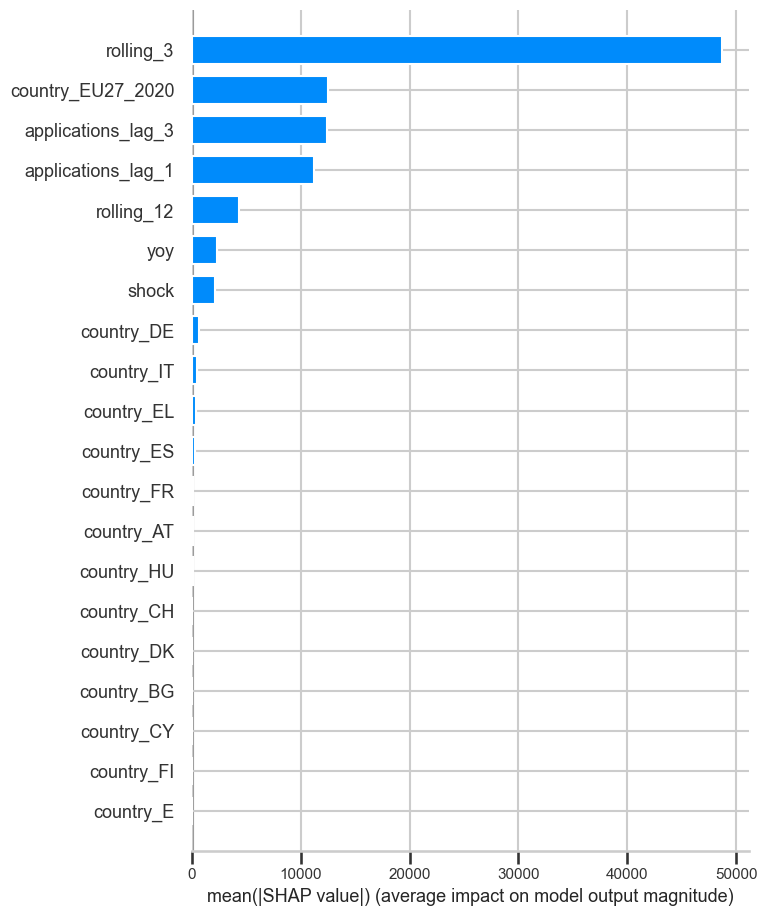

Top features by mean |SHAP|:
 rolling_3             48735.812549
country_EU27_2020     12479.371932
applications_lag_3    12367.801687
applications_lag_1    11230.931283
rolling_12             4315.904189
yoy                    2300.840933
shock                  2086.264534
country_DE              689.071734
country_IT              426.662589
country_EL              341.072783
dtype: float64


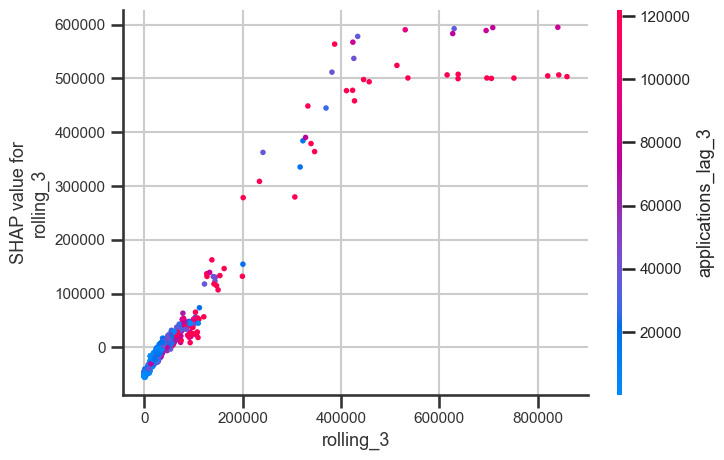

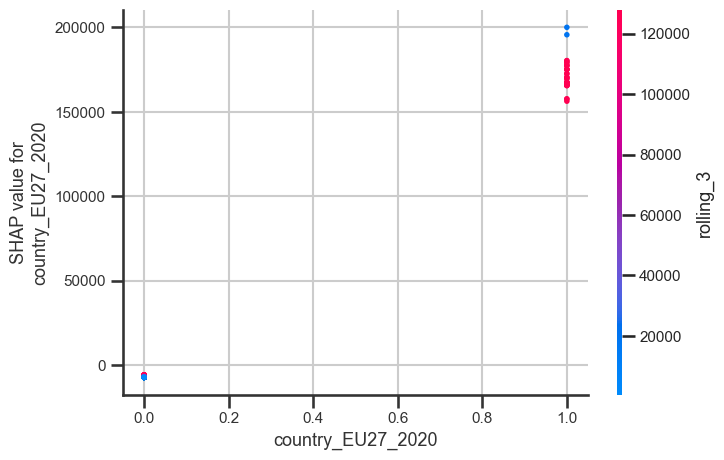

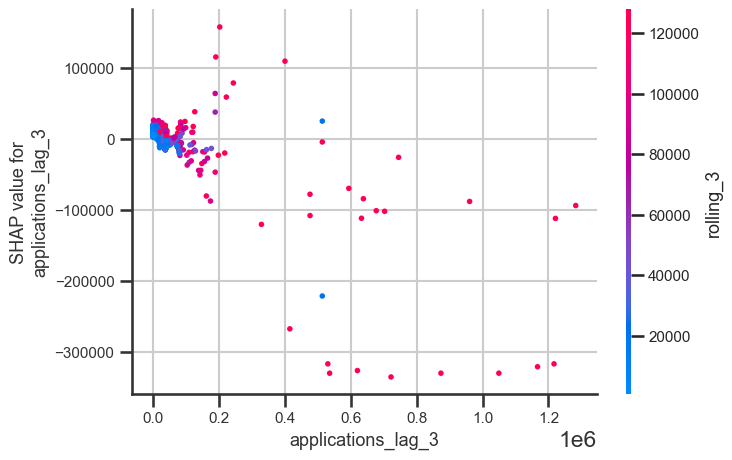

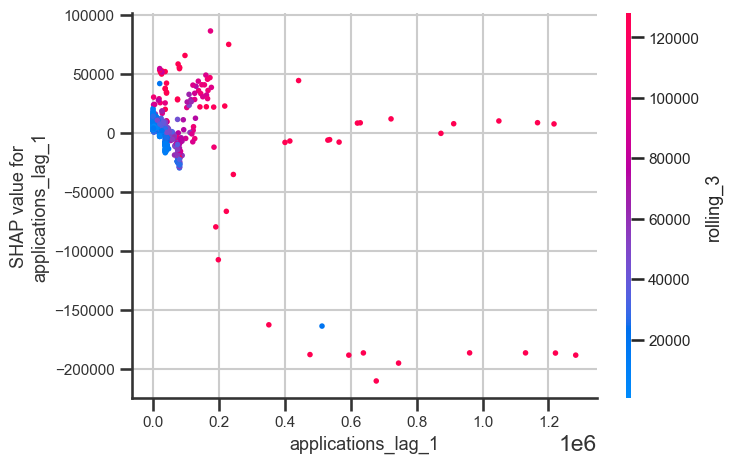

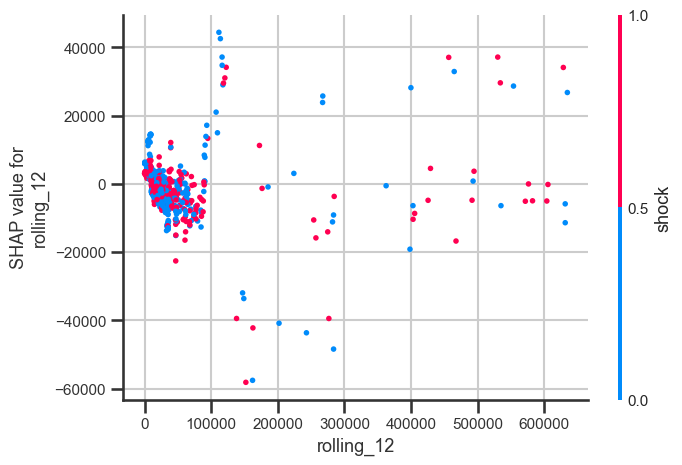

SHAP analysis failed: boolean index did not match indexed array along axis 0; size of axis is 1000 but size of corresponding boolean axis is 629
Proceeding without SHAP visualizations.


In [21]:
# SHAP explainability: safe execution with fallbacks
try:
    explainer = shap.TreeExplainer(final_model)
    sample = X.sample(min(1000, len(X)), random_state=SEED)
    shap_values = explainer.shap_values(sample)

    # Summary plot (global importance)
    shap.summary_plot(shap_values, sample, plot_type='bar', show=True)

    # Identify top features
    avg_abs = np.abs(shap_values).mean(axis=0)
    feat_importance = pd.Series(avg_abs, index=sample.columns).sort_values(ascending=False)
    print('Top features by mean |SHAP|:\n', feat_importance.head(10))

    # Dependence plots for top features
    top_feats = feat_importance.head(5).index.tolist()
    for f in top_feats:
        shap.dependence_plot(f, shap_values, sample, show=True)

    # Shock sensitivity: compare mean |SHAP| when shock=1 vs shock=0
    if 'shock' in X.columns and X['shock'].sum()>0:
        mask = X['shock']==1
        shock_mean_shap = np.abs(shap_values[mask.sample(min(1000, mask.sum()), random_state=SEED)]).mean(axis=0)
        shock_df = pd.Series(shock_mean_shap, index=sample.columns).sort_values(ascending=False)
        print('Top features more influential during shocks:\n', shock_df.head(10))
except Exception as e:
    print('SHAP analysis failed:', e)
    print('Proceeding without SHAP visualizations.')

**Plain language explanation:** SHAP shows how individual features (like recent lags, YoY, or country indicators) move predictions up/down. Countries with consistently large SHAP contributions during shock periods are identified as shock-sensitive and should be prioritized for monitoring and contingency planning.

## 6️⃣ Policy Conclusion

- Key insights: recent history (lags and rolling averages) and rapid YoY changes are the most consistent predictors of next-period asylum applications. Top contributing countries explain a disproportionate share of forecast errors and should be monitored more closely.

- Real-world implications: use model outputs to adjust reception capacity, pre-position resources, and coordinate cross-border support in identified hotspot countries.

- Ethics & caveats: forecasts are probabilistic and depend on reporting quality—avoid deterministic allocation solely on model outputs. Protect privacy when sharing microdata.

- Future work: integrate covariates (conflict incidence, mobility data, policy announcements), probabilistic forecasting, and calibrated uncertainty bands.

In [22]:
# Final checks
assert X.isna().sum().sum() == 0, 'There are still missing values in the feature matrix'
print('Final checks passed: no missing values in features. Ready to train and explain.')

Final checks passed: no missing values in features. Ready to train and explain.
